In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [27]:
# norm^2 is the same as the dot product of a vector with itself

a = np.array([[3, 4]]).T

print(a.T @ a)
print(np.linalg.norm(a)**2)

[[25]]
25.0


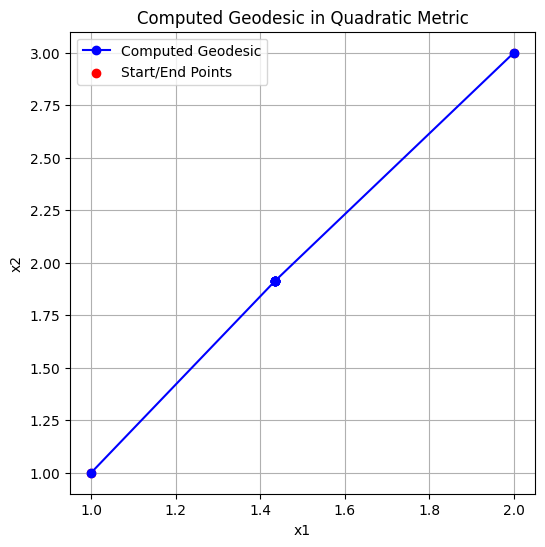

In [ ]:
# Exercise 6.4 a
G = lambda x : (1 + x.T @ x) * np.identity(2)

# Compute geodesic using piecewise linear approximation
def energy_function(piecewise_points, G):
    """
    Computes the energy of a piecewise linear curve given a metric.
    """
    CE = lambda v, x : v.T @ G(x) @ v  # Compute the energy of a curve segment
    piecewise_points = piecewise_points.reshape(-1, 2) # Reshape to array of points to (N, 2)
    total_energy = 0

    for i in range(len(piecewise_points) - 1):
        x = (piecewise_points[i] + piecewise_points[i+1]) / 2  # Midpoint (position)
        v = piecewise_points[i+1] - piecewise_points[i]  # Tangent vector (velocity)
        total_energy += CE(v, x)

    return total_energy

def compute_geodesic(start, end, num_points, G):
    """
    Computes the geodesic by minimizing the energy function.
    """
    # The points are initialized as equally spaced along a straight line between the start and end points.
    initial_guess = np.linspace(start, end, num_points)[1:-1].flatten()  # Exclude endpoints

    # The optimizer moves the intermediate points to reduce the total energy.
    # The start and end points do not change.
    # The number of intermediate points remains the same.
    result = minimize(energy_function, initial_guess, args=(G,), method="L-BFGS-B")
    optimized_points = result.x.reshape(-1, 2)

    return np.vstack([start, optimized_points, end])  # Include endpoints

# Define start and end points
start_point = np.array([1.0, 1.0])
end_point = np.array([2.0, 3.0])

# Compute geodesic in the quadratic metric
num_intermediate_points = 10
geodesic_points = compute_geodesic(start_point, end_point, num_intermediate_points, G)

# Plot the computed geodesic
plt.figure(figsize=(6,6))
plt.plot(geodesic_points[:, 0], geodesic_points[:, 1], 'bo-', label="Computed Geodesic")
plt.scatter([start_point[0], end_point[0]], [start_point[1], end_point[1]], color='red', label="Start/End Points")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("Computed Geodesic in Quadratic Metric")
plt.grid(True)
plt.show()

Optimized b: [1.32536874 1.32536874]
Optimized c: [-0.37369815 -0.37369815]
Computed d (from constraint): [0.04832941 0.04832941]
Minimum energy: 3.2326849565561893


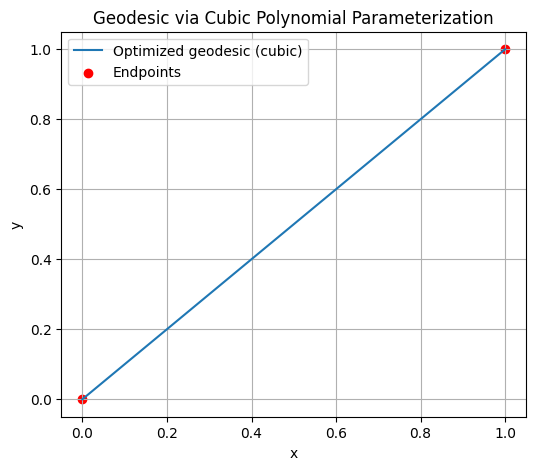

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Define the cubic polynomial with fixed endpoints.
# x0, x1 are endpoints; b and c are free parameters (each in R^2)
def c_poly(t, b, c, x0, x1):
    t = t[:, np.newaxis]  # reshape t to (n, 1) for broadcasting
    d = x1 - x0 - b - c   # compute d to satisfy c(1) = x1
    return x0 + b*t + c*t**2 + d*t**3

# Derivative of the polynomial.
def dc_poly(t, b, c, x0, x1):
    t = t[:, np.newaxis]  # reshape t to (n, 1)
    d = x1 - x0 - b - c
    return b + 2*c*t + 3*d*t**2

# Energy functional: integrates (1 + ||c(t)||^2) * ||c'(t)||^2 over t in [0,1]
def energy_function(params, x0, x1, t):
    # params contains [b0, b1, c0, c1]
    b = params[:2]
    c = params[2:]
    c_vals = c_poly(t, b, c, x0, x1)
    dc_vals = dc_poly(t, b, c, x0, x1)
    integrand = (1 + np.sum(c_vals**2, axis=1)) * np.sum(dc_vals**2, axis=1)
    # Use the trapezoidal rule over the original t (which is 1D)
    return np.trapz(integrand, t)

# Example endpoints
x0 = np.array([0.0, 0.0])
x1 = np.array([1.0, 1.0])

# Discretize t in [0,1]
t = np.linspace(0, 1, 100)

# Initial guess for the free parameters b and c.
# A reasonable guess is to take b and c in the direction of (x1-x0)
init_b = 0.5 * (x1 - x0)  # guess for b
init_c = 0.0 * (x1 - x0)  # guess for c (feel free to adjust)
init_guess = np.concatenate([init_b, init_c])

# Run the optimization to minimize the energy
result = minimize(energy_function, init_guess, args=(x0, x1, t), method='L-BFGS-B')
b_opt = result.x[:2]
c_opt = result.x[2:]
d_opt = x1 - x0 - b_opt - c_opt  # computed from the endpoint constraint

print("Optimized b:", b_opt)
print("Optimized c:", c_opt)
print("Computed d (from constraint):", d_opt)
print("Minimum energy:", result.fun)

# Evaluate the optimized curve
curve_opt = c_poly(t, b_opt, c_opt, x0, x1)

# Plot the geodesic and the endpoints
plt.figure(figsize=(6, 5))
plt.plot(curve_opt[:, 0], curve_opt[:, 1], label='Optimized geodesic (cubic)')
plt.scatter([x0[0], x1[0]], [x0[1], x1[1]], color='red', label='Endpoints')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Geodesic via Cubic Polynomial Parameterization")
plt.legend()
plt.grid(True)
plt.show()


In [64]:
# Exercise 6.5

# Load data in
data = np.load("toybanana.npy")
print(data.shape)

(992, 2)


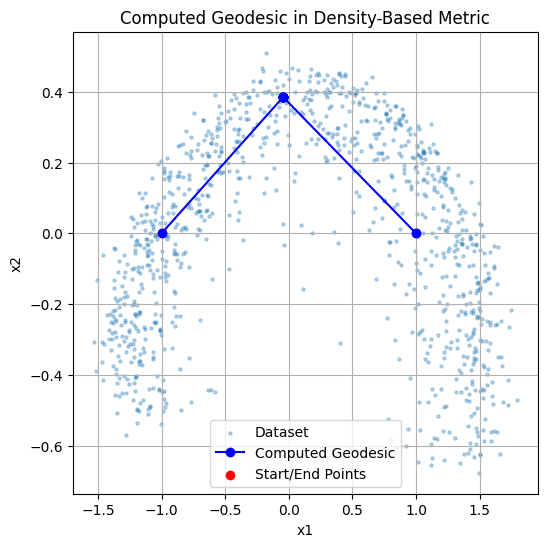

In [71]:
# Reload the dataset since execution state was reset
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Define density-based metric function
def density_metric(x, data, sigma=0.1, epsilon=1e-4):
    """
    Computes the density-based metric G(x) at a given point x using kernel density estimation.
    """
    N = len(data)
    density = np.sum(np.exp(-np.linalg.norm(x - data, axis=1)**2 / (2 * sigma**2))) / (N * sigma**2)
    return np.eye(2) / (density + epsilon)

# Compute geodesic using piecewise linear approximation
def energy_function(piecewise_points, metric_func, data):
    """
    Computes the energy of a piecewise linear curve given a metric.
    """
    piecewise_points = piecewise_points.reshape(-1, 2)
    total_energy = 0

    for i in range(len(piecewise_points) - 1):
        x = (piecewise_points[i] + piecewise_points[i+1]) / 2  # Midpoint
        v = piecewise_points[i+1] - piecewise_points[i]  # Tangent vector
        G = metric_func(x, data)
        energy = v.T @ G @ v  # Quadratic form in the metric
        total_energy += energy

    return total_energy

def compute_geodesic(start, end, num_points, metric_func, data):
    """
    Computes the geodesic by minimizing the energy function.
    """
    initial_guess = np.linspace(start, end, num_points)[1:-1].flatten()  # Exclude endpoints

    result = minimize(energy_function, initial_guess, args=(metric_func, data), method="L-BFGS-B")
    optimized_points = result.x.reshape(-1, 2)

    return np.vstack([start, optimized_points, end])  # Include endpoints

# Define start and end points
start_point = np.array([-1.0, 0.0])
end_point = np.array([1.0, 0.0])

# Compute geodesic in density-based metric
num_intermediate_points = 10
geodesic_points_density = compute_geodesic(start_point, end_point, num_intermediate_points, density_metric, data)

# Plot the computed geodesic over the dataset
plt.figure(figsize=(6,6))
plt.scatter(data[:, 0], data[:, 1], s=5, alpha=0.3, label="Dataset")
plt.plot(geodesic_points_density[:, 0], geodesic_points_density[:, 1], 'bo-', label="Computed Geodesic")
plt.scatter([start_point[0], end_point[0]], [start_point[1], end_point[1]], color='red', label="Start/End Points")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("Computed Geodesic in Density-Based Metric")
plt.grid(True)
plt.show()